In [15]:
from pathlib import Path
from make_gorilla_curl import load_sample_json, generate_curl_command
import sys
from pathlib import Path
sys.path.append(str(Path(__file__).resolve().parent))
from berkeley_error_report import SCORE_DIR, OUTPUT_CSV_TEMPLATE, collect_error_data, write_csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

# Generate error report

In [16]:
report_id = "2025-06-19-23-36-53"
rows = collect_error_data(SCORE_DIR, report_id)
output_report_path = Path(OUTPUT_CSV_TEMPLATE.format(target_id=report_id))
write_csv(rows, output_report_path)
print(f"Report saved to {output_report_path}")

Report saved to results/fc-so-testing-suite/gorilla_snova/2025-06-19-23-36-53/berkeley_test_error_report.csv


# Utilities

In [17]:
model_mapping={
    "sambanova_Meta-Llama-3.1-405B-Instruct-FC": "Meta-Llama-3.1-405B-Instruct",
    "fireworks_accounts_fireworks_models_llama-v3p1-405b-instruct-FC": "Meta-Llama-3.1-405B-Instruct",
    "fireworks_accounts_fireworks_models_llama-v3p1-405b-instruct-long-FC": "Meta-Llama-3.1-405B-Instruct",
    "together_meta-llama_Meta-Llama-3.1-405B-Instruct-Turbo-FC": "Meta-Llama-3.1-405B-Instruct",

    "sambanova_Meta-Llama-3.3-70B-Instruct-FC": "Meta-Llama-3.3-70B-Instruct",
    "fireworks_accounts_fireworks_models_llama-v3p3-70b-instruct-FC": "Meta-Llama-3.3-70B-Instruct",
    "groq_llama-3.3-70b-versatile-FC": "Meta-Llama-3.3-70B-Instruct",
    "cerebras_llama-3.3-70b-FC": "Meta-Llama-3.3-70B-Instruct",
    "together_meta-llama_Llama-3.3-70B-Instruct-Turbo-Free-FC": "Meta-Llama-3.3-70B-Instruct",

    "sambanova_Llama-4-Scout-17B-16E-Instruct-FC": "Llama-4-Scout-17B-16E-Instruct",
    "fireworks_accounts_fireworks_models_llama4-scout-instruct-basic-FC": "Llama-4-Scout-17B-16E-Instruct",
    "groq_meta-llama_llama-4-scout-17b-16e-instruct-FC": "Llama-4-Scout-17B-16E-Instruct",
    "cerebras_llama-4-scout-17b-16e-instruct-FC": "Llama-4-Scout-17B-16E-Instruct",
    "together_meta-llama_Llama-4-Scout-17B-16E-Instruct-FC": "Llama-4-Scout-17B-16E-Instruct",

    "sambanova_Llama-4-Maverick-17B-128E-Instruct-FC": "Llama-4-Maverick-17B-128E-Instruct",
    "fireworks_accounts_fireworks_models_llama4-maverick-instruct-basic-FC": "Llama-4-Maverick-17B-128E-Instruct",
    "groq_meta-llama_llama-4-maverick-17b-128e-instruct-FC": "Llama-4-Maverick-17B-128E-Instruct",
    "together_meta-llama_Llama-4-Maverick-17B-128E-Instruct-FP8-FC": "Llama-4-Maverick-17B-128E-Instruct",

    "sambanova_DeepSeek-V3-0324-FC": "DeepSeek-V3-0324",
    "fireworks_accounts_fireworks_models_deepseek-v3-0324-FC": "DeepSeek-V3-0324",
    "together_deepseek-ai_DeepSeek-V3-FC": "DeepSeek-V3-0324",

    "sambanova_Qwen3-32B-FC": "Qwen3-32B",
    "fireworks_accounts_fireworks_models_qwen3-30b-a3b-FC": "Qwen3-32B",
    "cerebras_qwen-3-32b-FC": "Qwen3-32B",
    "together_Qwen_Qwen3-235B-A22B-fp8-tput-FC": "Qwen3-32B"
}

In [18]:
def normalize_model_name(model_name):
    model_name=model_mapping[model_name]
    return model_name

In [19]:
def lighten_hex(hex_color, amount=0.5):
    """Lightens a hex color by mixing it with white (amount = 0 to 1)."""
    hex_color = hex_color.lstrip("#")
    
    # Remove alpha if present
    if len(hex_color) == 8:
        hex_color = hex_color[:6]

    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    r_l = int(r + (255 - r) * amount)
    g_l = int(g + (255 - g) * amount)
    b_l = int(b + (255 - b) * amount)
    
    return "#{:02x}{:02x}{:02x}".format(r_l, g_l, b_l)

provider_colors = {
    'sambanova': "#ED7E00", 
    'groq': '#FF0000',  
    'cerebras': "#FFEE00",   
    'fireworks': "#690069", 
    'together': "#00007C",    
}

provider_colors = {
    provider: lighten_hex(color, amount=0.25)
    for provider, color in provider_colors.items()
}

In [20]:
def wrap_label(label, break_chars=('_', ':'), max_total_length=20):
    label = str(label)
    
    # Only wrap if label exceeds max length
    if len(label) <= max_total_length:
        return label
    
    # Split on break characters, keeping them in the result
    import re
    parts = re.split(f"([{''.join(map(re.escape, break_chars))}])", label)
    
    # Reconstruct with line breaks after break chars
    wrapped = ''
    line_length = 0
    for part in parts:
        if part in break_chars:
            wrapped += part
            line_length += len(part)
        else:
            if line_length + len(part) > max_total_length:
                wrapped += '\n' + part
                line_length = len(part)
            else:
                wrapped += part
                line_length += len(part)
    
    return wrapped

# Read report

In [21]:
df = pd.read_csv(output_report_path, sep = ";")
df.head()

,run_id,id_test,provider,test,model,error,error_type
0,2025-06-19-23-36-53,simple_79,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed
1,2025-06-19-23-36-53,simple_81,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed
2,2025-06-19-23-36-53,simple_83,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed
3,2025-06-19-23-36-53,simple_150,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid value for parameter 'annual_interest_r...,value_error:others
4,2025-06-19-23-36-53,simple_161,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed


In [22]:
df['test_type'] = df['id_test'].str.extract(r'^(simple|live_parallel|multiple|parallel_multiple|multi_turn_base|multi_turn_long_context)')
df.head()

,run_id,id_test,provider,test,model,error,error_type,test_type
0,2025-06-19-23-36-53,simple_79,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed,simple
1,2025-06-19-23-36-53,simple_81,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed,simple
2,2025-06-19-23-36-53,simple_83,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed,simple
3,2025-06-19-23-36-53,simple_150,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid value for parameter 'annual_interest_r...,value_error:others,simple
4,2025-06-19-23-36-53,simple_161,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed,simple


In [23]:
df['normalized_model'] = df['model'].apply(normalize_model_name)
df.head()

,run_id,id_test,provider,test,model,error,error_type,test_type,normalized_model
0,2025-06-19-23-36-53,simple_79,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed,simple,DeepSeek-V3-0324
1,2025-06-19-23-36-53,simple_81,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed,simple,DeepSeek-V3-0324
2,2025-06-19-23-36-53,simple_83,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed,simple,DeepSeek-V3-0324
3,2025-06-19-23-36-53,simple_150,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid value for parameter 'annual_interest_r...,value_error:others,simple,DeepSeek-V3-0324
4,2025-06-19-23-36-53,simple_161,sambanova,BFCL_v3_simple_score.json,sambanova_DeepSeek-V3-0324-FC,Invalid syntax. Failed to decode AST. 'str' ob...,ast_decoder:decoder_failed,simple,DeepSeek-V3-0324


# Errors report chart per test 

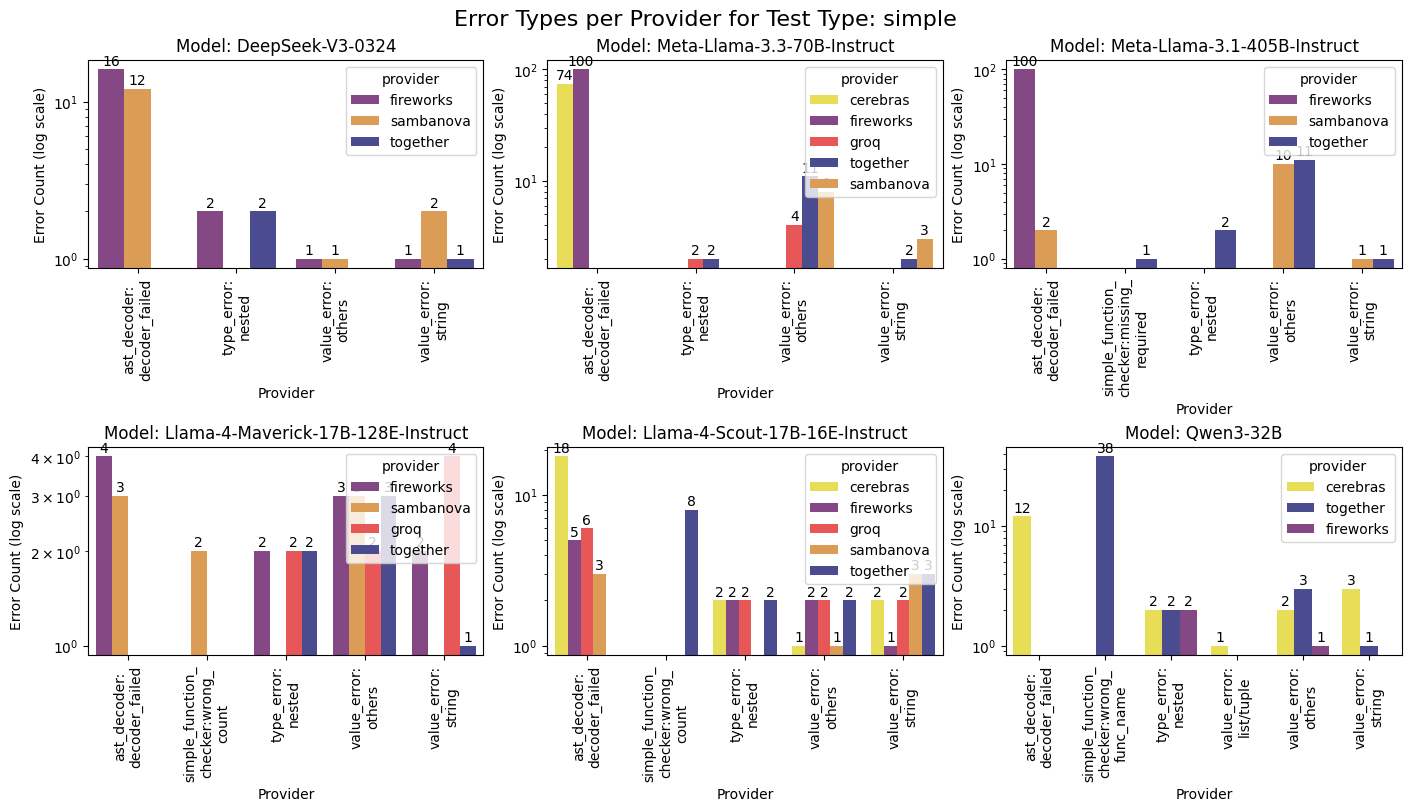

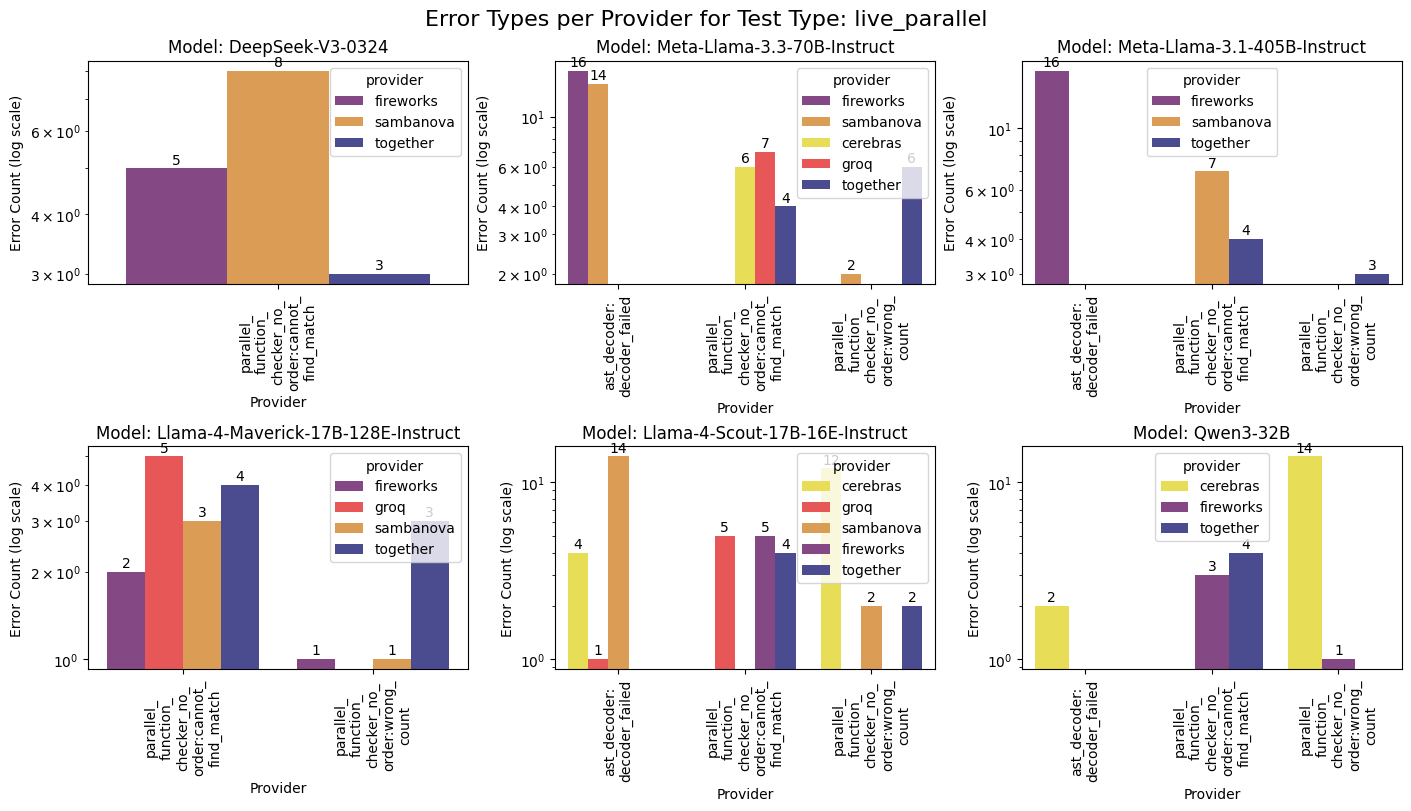

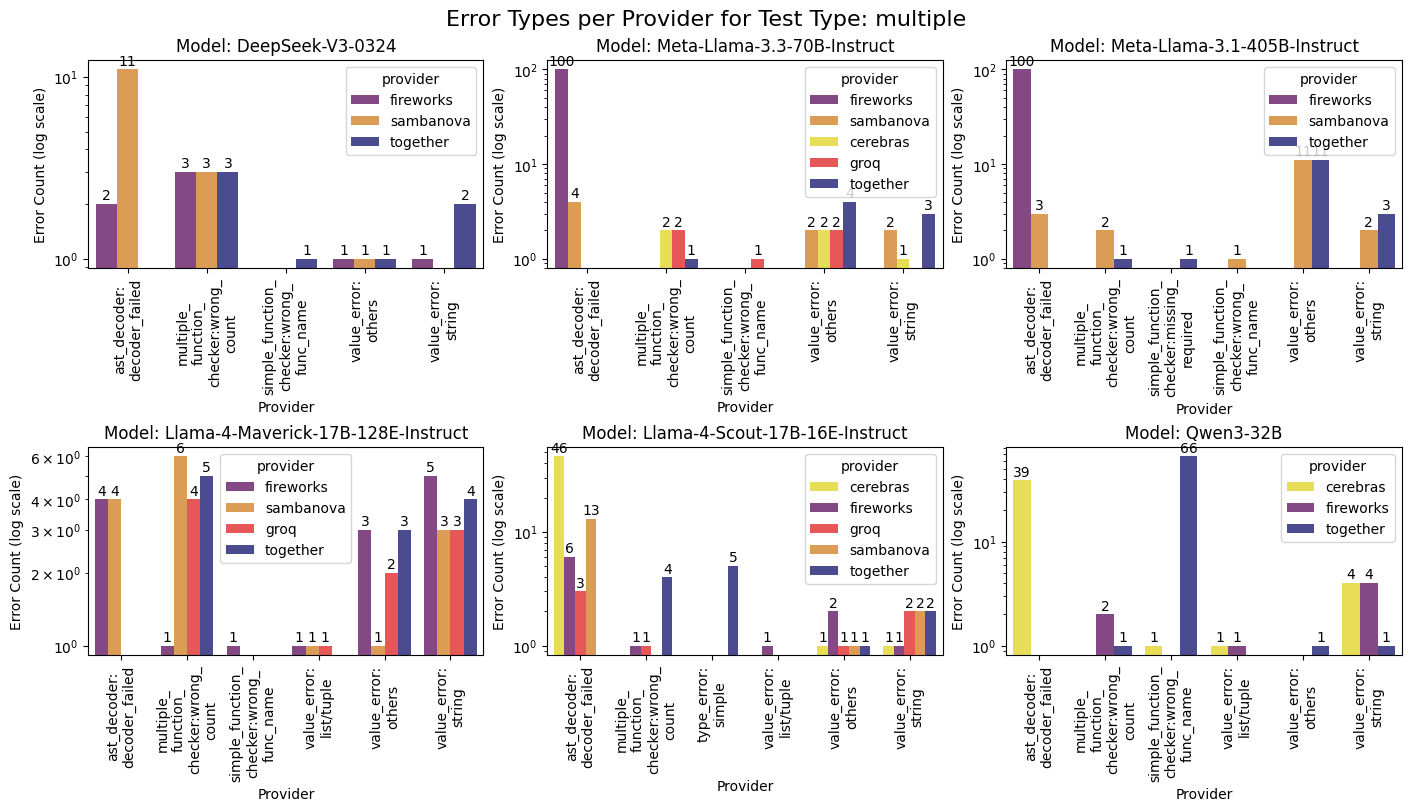

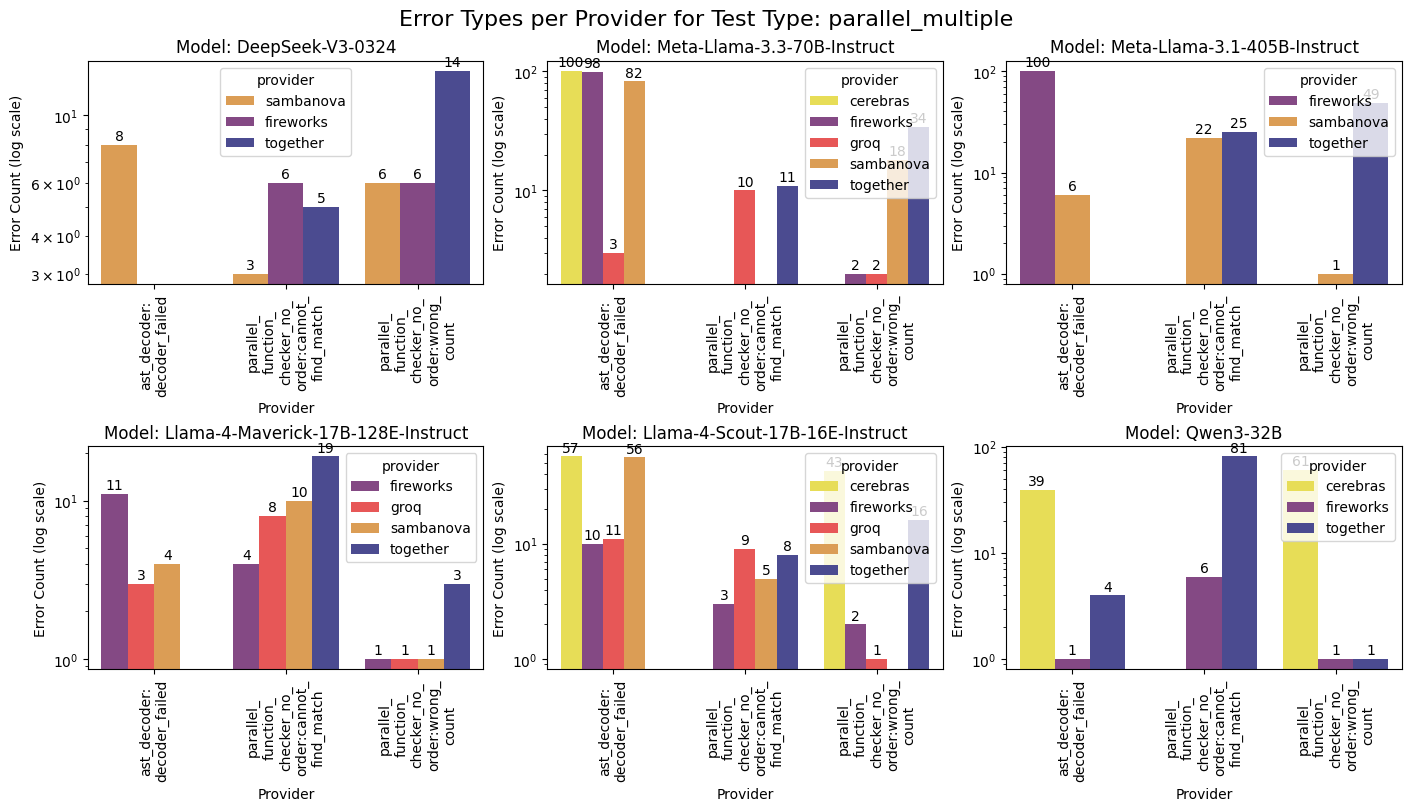

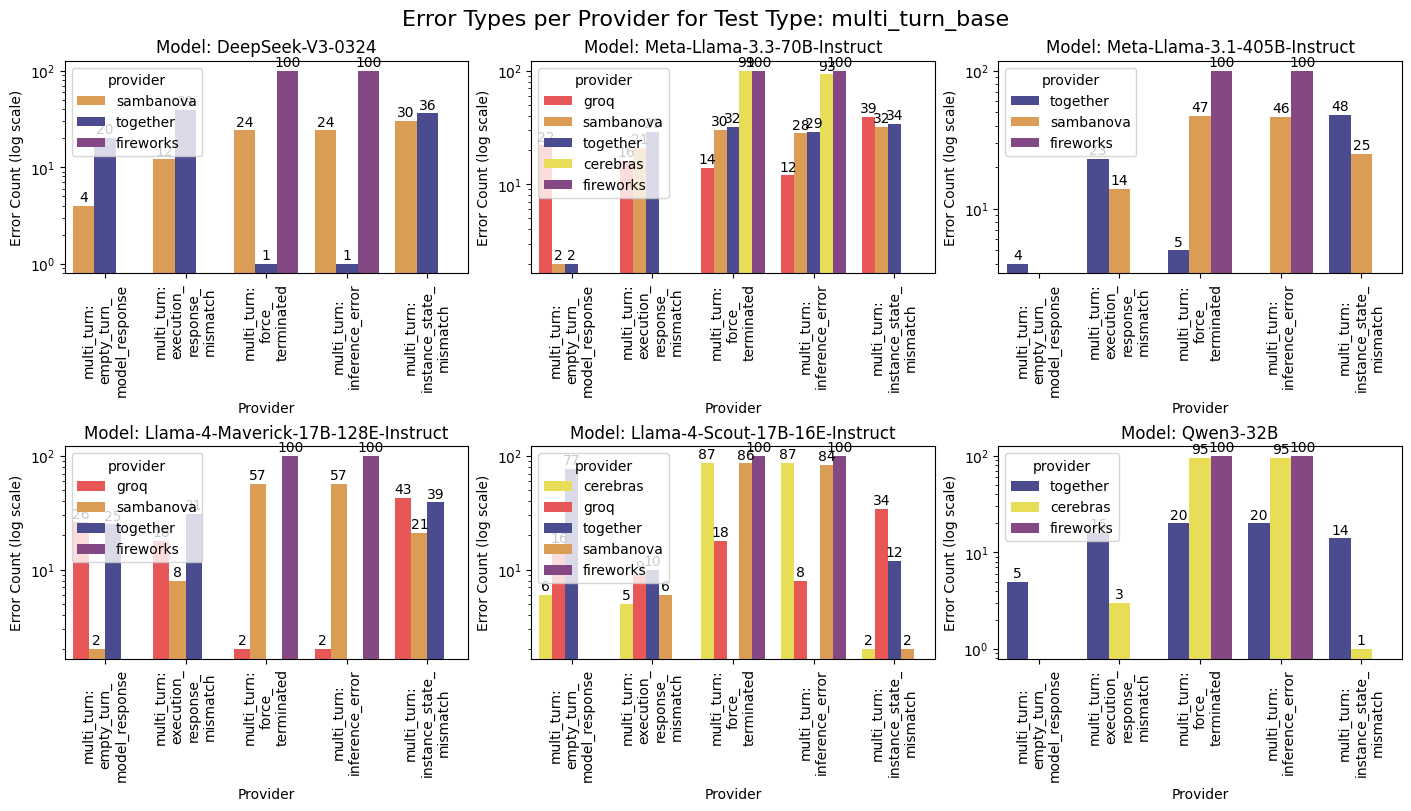

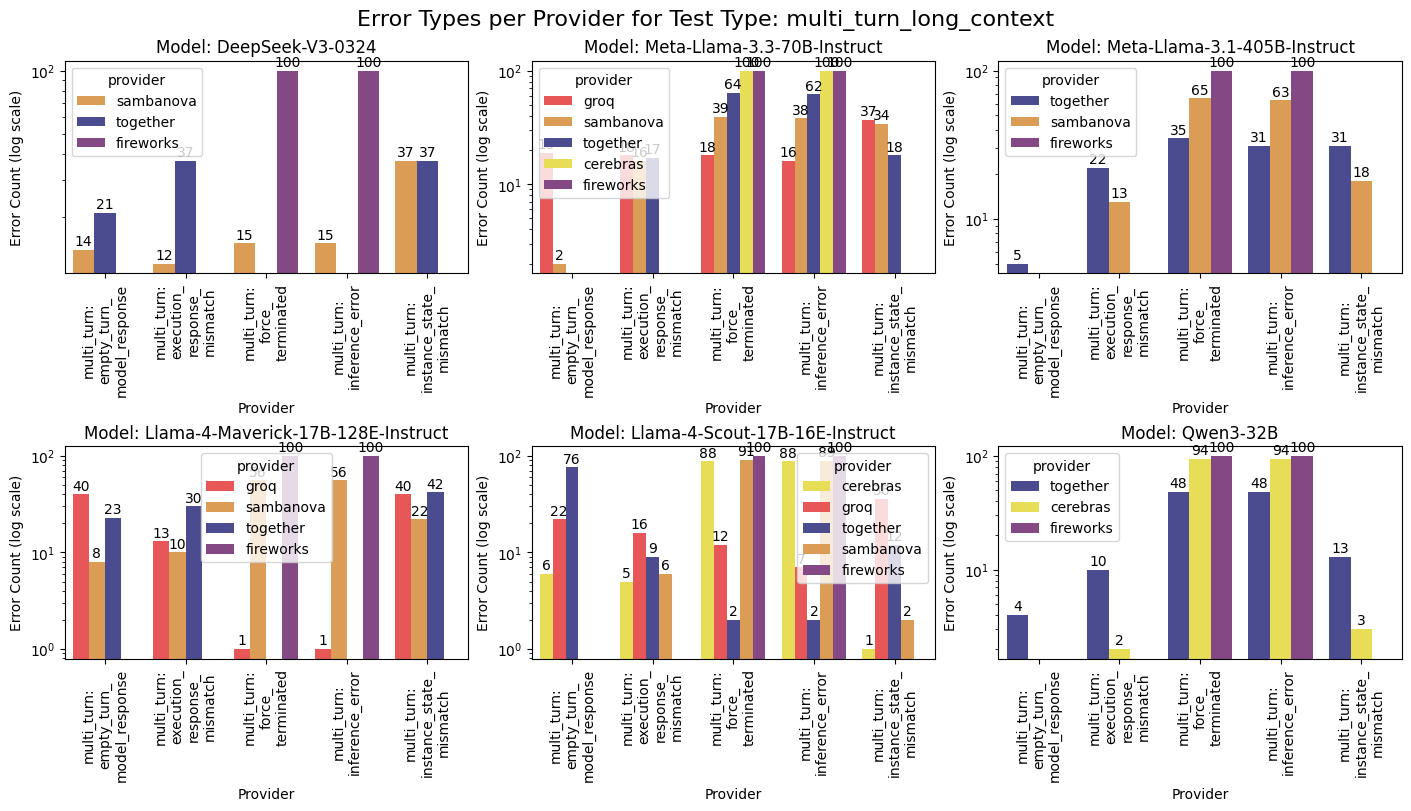

In [24]:
test_types = ['simple', 'live_parallel', 'multiple', 'parallel_multiple', 'multi_turn_base', 'multi_turn_long_context']


for test_type in test_types:
    df_test = df[df['test_type'] == test_type]
    if len(df_test) > 0:
        models = df_test['normalized_model'].unique()
        n_models = len(models)

        fig, axes = plt.subplots(
            nrows=(n_models + 1) // 3,
            ncols=3,
            figsize=(14, 4 * ((n_models + 1) // 3)),
            constrained_layout=True
        )
        axes = axes.flatten()

        for idx, model in enumerate(models):
            ax = axes[idx]
            df_model = df_test[df_test['normalized_model'] == model]

            summary = df_model.groupby(['error_type', 'provider']).size().reset_index(name='count')
            summary['error_type_wrapped'] = summary['error_type'].apply(lambda x: wrap_label(str(x), max_total_length=15))

            sns.barplot(
                data=summary,
                x='error_type_wrapped',
                y='count',
                hue='provider',
                palette=provider_colors,
                ax=ax
            )

            ax.set_title(f"Model: {model}")
            ax.set_yscale("log")
            ax.set_ylabel("Error Count (log scale)")
            ax.set_xlabel("Provider")
            ax.tick_params(axis='x', rotation=90)
        
            for container in ax.containers:
                ax.bar_label(container, fmt='%.0f', label_type='edge', padding=1)

        # Remove unused axes
        for j in range(idx + 1, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"Error Types per Provider for Test Type: {test_type}", fontsize=16)
        plt.show()
        output_dir = output_report_path.parent / "charts"
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_dir/f"errors_{test_type}.png", dpi=300)

# Error count

In [25]:
error_counts = df.groupby(['test_type', 'normalized_model', 'provider', 'error_type']).size().reset_index(name='count').sort_values(["test_type","count"],ascending=False)

In [26]:
len(error_counts["error_type"].unique())

17

In [27]:
error_counts[error_counts["provider"]=="sambanova"]

,test_type,normalized_model,provider,error_type,count
347,simple,DeepSeek-V3-0324,sambanova,ast_decoder:decoder_failed,12
386,simple,Meta-Llama-3.1-405B-Instruct,sambanova,value_error:others,10
396,simple,Meta-Llama-3.3-70B-Instruct,sambanova,value_error:others,8
359,simple,Llama-4-Maverick-17B-128E-Instruct,sambanova,ast_decoder:decoder_failed,3
361,simple,Llama-4-Maverick-17B-128E-Instruct,sambanova,value_error:others,3
...,...,...,...,...,...
20,live_parallel,Meta-Llama-3.1-405B-Instruct,sambanova,parallel_function_checker_no_order:cannot_find...,7
6,live_parallel,Llama-4-Maverick-17B-128E-Instruct,sambanova,parallel_function_checker_no_order:cannot_find...,3
16,live_parallel,Llama-4-Scout-17B-16E-Instruct,sambanova,parallel_function_checker_no_order:wrong_count,2
27,live_parallel,Meta-Llama-3.3-70B-Instruct,sambanova,parallel_function_checker_no_order:wrong_count,2


# sample rows for each combination of test_type and error_type

In [19]:
# Filter only sambanova errors
df_sambanova = df[df['provider'] == 'sambanova']

# Then sample one row per test_type + error_type
sampled_rows = df_sambanova.groupby(['test_type', 'error_type'], group_keys=False).apply(
    lambda x: x.sample(1, random_state=42)
)

#keep only relevant columns
sampled_rows = sampled_rows[['run_id', 'id_test', 'provider', 'model', 'error_type' , 'error']]

# Display
sampled_rows

,run_id,id_test,provider,model,error_type,error
371,2025-06-19-23-36-53,live_parallel_10-6-0,sambanova,sambanova_Meta-Llama-3.3-70B-Instruct-FC,ast_decoder:decoder_failed,Invalid syntax. Failed to decode AST. 'str' ob...
47,2025-06-19-23-36-53,live_parallel_0-0-0,sambanova,sambanova_DeepSeek-V3-0324-FC,parallel_function_checker_no_order:cannot_find...,Could not find a matching function among index...
376,2025-06-19-23-36-53,live_parallel_15-11-0,sambanova,sambanova_Meta-Llama-3.3-70B-Instruct-FC,parallel_function_checker_no_order:wrong_count,Wrong number of functions.
195,2025-06-19-23-36-53,multi_turn_base_107,sambanova,sambanova_DeepSeek-V3-0324-FC,multi_turn:empty_turn_model_response,Model response list is empty for turn 2
151,2025-06-19-23-36-53,multi_turn_base_7,sambanova,sambanova_DeepSeek-V3-0324-FC,multi_turn:execution_response_mismatch,Model response execution results so far does n...
507,2025-06-19-23-36-53,multi_turn_base_4,sambanova,sambanova_Meta-Llama-3.3-70B-Instruct-FC,multi_turn:force_terminated,Model was force-terminated during inference ph...
506,2025-06-19-23-36-53,multi_turn_base_4,sambanova,sambanova_Meta-Llama-3.3-70B-Instruct-FC,multi_turn:inference_error,Error during inference phase. Model did not ou...
938,2025-06-19-23-36-53,multi_turn_base_131,sambanova,sambanova_Meta-Llama-3.1-405B-Instruct-FC,multi_turn:instance_state_mismatch,Model instance for TradingBot does not match t...
118,2025-06-19-23-36-53,multi_turn_long_context_137,sambanova,sambanova_DeepSeek-V3-0324-FC,multi_turn:empty_turn_model_response,Model response list is empty for turn 3
60,2025-06-19-23-36-53,multi_turn_long_context_9,sambanova,sambanova_DeepSeek-V3-0324-FC,multi_turn:execution_response_mismatch,Model response execution results so far does n...


In [50]:
# generate curls
def get_curl(row):
    sample_error_json = load_sample_json(
        run_id=row["run_id"],
        raw_model_name=row["model"],
        sample_id=row["id_test"]
    )
    return generate_curl_command(data=sample_error_json)

sampled_rows["curl"]=sampled_rows.apply(get_curl, axis=1)

def print_curls(sampled_rows):
    for index, row in sampled_rows.iterrows():
        print("\n\n------------------------------------------------------------------------------------------------")
        print(f"------ Sample curl for error {row['error_type']}")
        print(f"------ test {row['id_test']} model: {row['model']}")
        print("------------------------------------------------------------------------------------------------\n")
        print(row["curl"])

In [53]:
#print_curls(sampled_rows)